In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
from PIL import Image

In [2]:
DATA_PATH = "/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
CLASSES = ["benign", "malignant", "normal"]
LABEL_DICT = {"benign": 0, "malignant": 1, "normal": 2}
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4
RANDOM_STATE = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [3]:
paths = []
labels = []
for cls in CLASSES:
    folder = os.path.join(DATA_PATH, cls)
    for img_name in os.listdir(folder):
        if "_mask" not in img_name:
            paths.append(os.path.join(folder, img_name))
            labels.append(cls)
data = pd.DataFrame({"path": paths, "label": labels})
print("Class Distribution:")
print(data["label"].value_counts())
print(f"\nTotal images: {len(data)}")

Class Distribution:
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64

Total images: 780


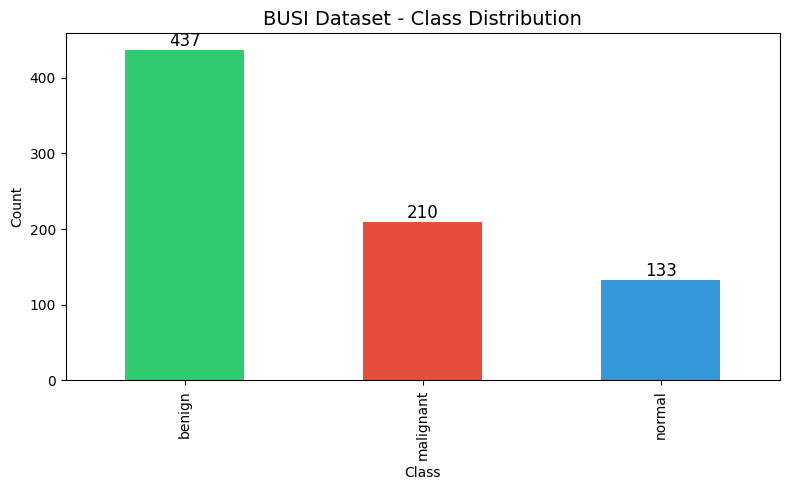

In [4]:
plt.figure(figsize=(8, 5))
ax = data["label"].value_counts().plot(kind="bar", color=["#2ecc71", "#e74c3c", "#3498db"])
ax.set_title("BUSI Dataset - Class Distribution", fontsize=14)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
data["label"] = data["label"].map(LABEL_DICT)
train_df, temp_df = train_test_split(
    data, test_size=0.30, stratify=data["label"], random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_STATE
)
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 546
Validation size: 117
Test size: 117


In [6]:
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])

In [7]:
class BUSIDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, index):
        img_path = self.df.iloc[index]["path"]
        label = self.df.iloc[index]["label"]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, label

In [8]:
train_dataset = BUSIDataset(train_df, basic_transform)
val_dataset = BUSIDataset(val_df, basic_transform)
test_dataset = BUSIDataset(test_df, basic_transform)
train_dataset_aug = BUSIDataset(train_df, aug_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [14]:
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 3)
    return model.to(device)

In [15]:
def train_model(model, train_ldr, val_ldr, criterion, optimizer, epochs=EPOCHS):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_ldr:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_ldr:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()
        print(f"  Epoch {epoch+1}/{epochs}  "
              f"Train Loss: {train_loss/len(train_ldr):.4f}  "
              f"Val Loss: {val_loss/len(val_ldr):.4f}")


In [16]:
results = {}
def evaluate_model(model, model_name):
    model.eval()
    preds = []
    true = []
    with torch.no_grad():
        for images, lbls in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            true.extend(lbls.numpy())
    acc = accuracy_score(true, preds)
    precision = precision_score(true, preds, average='macro')
    recall = recall_score(true, preds, average='macro')
    f1 = f1_score(true, preds, average='macro')
    results[model_name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
    }
    print(f"\n{'='*40}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*40}")
    print(classification_report(true, preds, target_names=CLASSES))
    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [17]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()
    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss
        return loss

  Epoch 1/15  Train Loss: 0.7969  Val Loss: 1.1698
  Epoch 2/15  Train Loss: 0.1959  Val Loss: 0.7097
  Epoch 3/15  Train Loss: 0.0877  Val Loss: 0.3809
  Epoch 4/15  Train Loss: 0.0830  Val Loss: 0.3583
  Epoch 5/15  Train Loss: 0.0869  Val Loss: 0.3220
  Epoch 6/15  Train Loss: 0.0639  Val Loss: 0.3099
  Epoch 7/15  Train Loss: 0.0255  Val Loss: 0.2891
  Epoch 8/15  Train Loss: 0.0317  Val Loss: 0.2796
  Epoch 9/15  Train Loss: 0.0462  Val Loss: 0.2845
  Epoch 10/15  Train Loss: 0.0520  Val Loss: 0.2864
  Epoch 11/15  Train Loss: 0.0636  Val Loss: 0.3105
  Epoch 12/15  Train Loss: 0.0264  Val Loss: 0.2887
  Epoch 13/15  Train Loss: 0.0464  Val Loss: 0.3156
  Epoch 14/15  Train Loss: 0.0829  Val Loss: 0.3064
  Epoch 15/15  Train Loss: 0.0690  Val Loss: 0.2785

  Baseline — Test Results
              precision    recall  f1-score   support

      benign       0.84      0.82      0.83        66
   malignant       0.74      0.81      0.77        31
      normal       0.79      0.75      

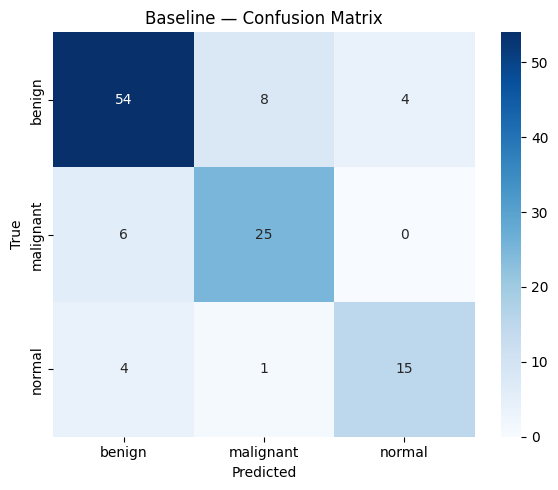

In [18]:
baseline_model = build_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=LR)
train_model(baseline_model, train_loader, val_loader, criterion, optimizer)
evaluate_model(baseline_model, "Baseline")


  Epoch 1/15  Train Loss: 0.6371  Val Loss: 0.8107
  Epoch 2/15  Train Loss: 0.1845  Val Loss: 0.6244
  Epoch 3/15  Train Loss: 0.1484  Val Loss: 0.3956
  Epoch 4/15  Train Loss: 0.1076  Val Loss: 0.3925
  Epoch 5/15  Train Loss: 0.0688  Val Loss: 0.3816
  Epoch 6/15  Train Loss: 0.0414  Val Loss: 0.3314
  Epoch 7/15  Train Loss: 0.0311  Val Loss: 0.2761
  Epoch 8/15  Train Loss: 0.0125  Val Loss: 0.2488
  Epoch 9/15  Train Loss: 0.0120  Val Loss: 0.2210
  Epoch 10/15  Train Loss: 0.2131  Val Loss: 0.2668
  Epoch 11/15  Train Loss: 0.1394  Val Loss: 0.3692
  Epoch 12/15  Train Loss: 0.1789  Val Loss: 0.3082
  Epoch 13/15  Train Loss: 0.2093  Val Loss: 0.3083
  Epoch 14/15  Train Loss: 0.1361  Val Loss: 0.3696
  Epoch 15/15  Train Loss: 0.0969  Val Loss: 0.3200

  Oversampling — Test Results
              precision    recall  f1-score   support

      benign       0.85      0.80      0.83        66
   malignant       0.72      0.84      0.78        31
      normal       0.79      0.75  

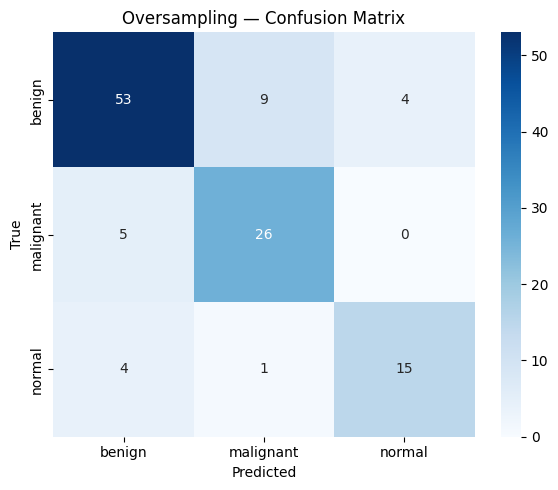

In [19]:
class_count = train_df["label"].value_counts().sort_index()
weights = 1.0 / torch.tensor(class_count.values, dtype=torch.float)
sample_weights = weights[train_df["label"].values]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)
train_loader_over = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
oversample_model = build_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(oversample_model.parameters(), lr=LR)
train_model(oversample_model, train_loader_over, val_loader, criterion, optimizer)
evaluate_model(oversample_model, "Oversampling")

  Epoch 1/15  Train Loss: 0.8051  Val Loss: 0.5866
  Epoch 2/15  Train Loss: 0.5105  Val Loss: 0.5281
  Epoch 3/15  Train Loss: 0.3554  Val Loss: 0.5181
  Epoch 4/15  Train Loss: 0.3116  Val Loss: 0.4295
  Epoch 5/15  Train Loss: 0.2504  Val Loss: 0.2795
  Epoch 6/15  Train Loss: 0.2205  Val Loss: 0.3051
  Epoch 7/15  Train Loss: 0.2047  Val Loss: 0.3550
  Epoch 8/15  Train Loss: 0.1844  Val Loss: 0.2949
  Epoch 9/15  Train Loss: 0.1426  Val Loss: 0.3083
  Epoch 10/15  Train Loss: 0.1909  Val Loss: 0.2982
  Epoch 11/15  Train Loss: 0.1680  Val Loss: 0.4846
  Epoch 12/15  Train Loss: 0.1573  Val Loss: 0.3607
  Epoch 13/15  Train Loss: 0.1419  Val Loss: 0.3293
  Epoch 14/15  Train Loss: 0.1526  Val Loss: 0.3005
  Epoch 15/15  Train Loss: 0.1141  Val Loss: 0.2638

  Augmentation — Test Results
              precision    recall  f1-score   support

      benign       0.85      0.83      0.84        66
   malignant       0.76      0.81      0.78        31
      normal       0.84      0.80  

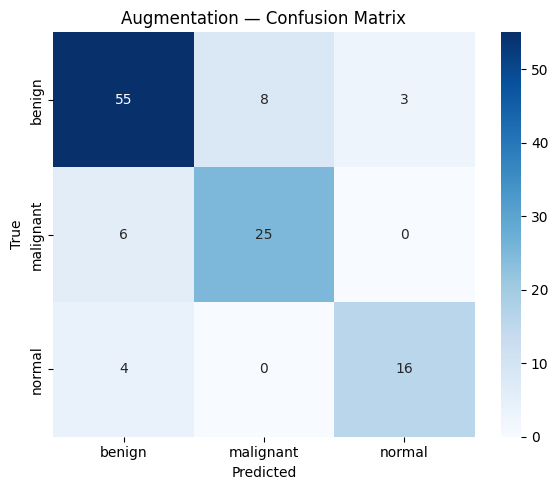

In [20]:
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
augment_model = build_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(augment_model.parameters(), lr=LR)
train_model(augment_model, train_loader_aug, val_loader, criterion, optimizer)
evaluate_model(augment_model, "Augmentation")


  Epoch 1/15  Train Loss: 0.2085  Val Loss: 0.3403
  Epoch 2/15  Train Loss: 0.0103  Val Loss: 0.1683
  Epoch 3/15  Train Loss: 0.0069  Val Loss: 0.0758
  Epoch 4/15  Train Loss: 0.0040  Val Loss: 0.0724
  Epoch 5/15  Train Loss: 0.0248  Val Loss: 0.0525
  Epoch 6/15  Train Loss: 0.0128  Val Loss: 0.0538
  Epoch 7/15  Train Loss: 0.0103  Val Loss: 0.0703
  Epoch 8/15  Train Loss: 0.0092  Val Loss: 0.0570
  Epoch 9/15  Train Loss: 0.0058  Val Loss: 0.1094
  Epoch 10/15  Train Loss: 0.0051  Val Loss: 0.0656
  Epoch 11/15  Train Loss: 0.0021  Val Loss: 0.0497
  Epoch 12/15  Train Loss: 0.0463  Val Loss: 0.0504
  Epoch 13/15  Train Loss: 0.0146  Val Loss: 0.1064
  Epoch 14/15  Train Loss: 0.0075  Val Loss: 0.0514
  Epoch 15/15  Train Loss: 0.0023  Val Loss: 0.0494

  Focal Loss — Test Results
              precision    recall  f1-score   support

      benign       0.83      0.76      0.79        66
   malignant       0.67      0.77      0.72        31
      normal       0.71      0.75    

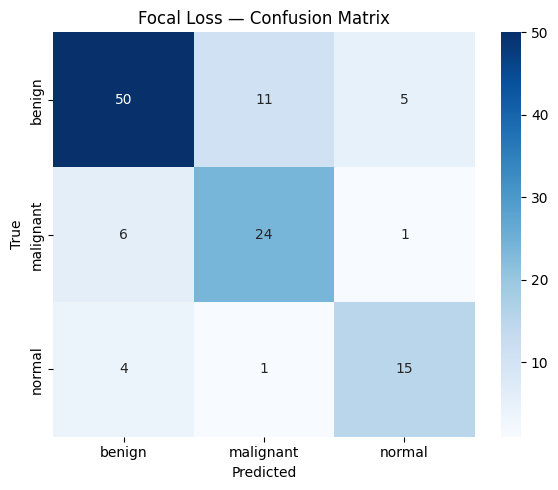

In [21]:
focal_model = build_model()
criterion = FocalLoss()
optimizer = optim.Adam(focal_model.parameters(), lr=LR)
train_model(focal_model, train_loader, val_loader, criterion, optimizer)
evaluate_model(focal_model, "Focal Loss")



Final Model Comparison

              Accuracy  Precision    Recall  F1 Score
Baseline      0.803419   0.789506  0.791544  0.789744
Oversampling  0.803419   0.788845  0.797247  0.791158
Augmentation  0.820513   0.815278  0.813262  0.813819
Focal Loss    0.760684   0.738095  0.760590  0.747259


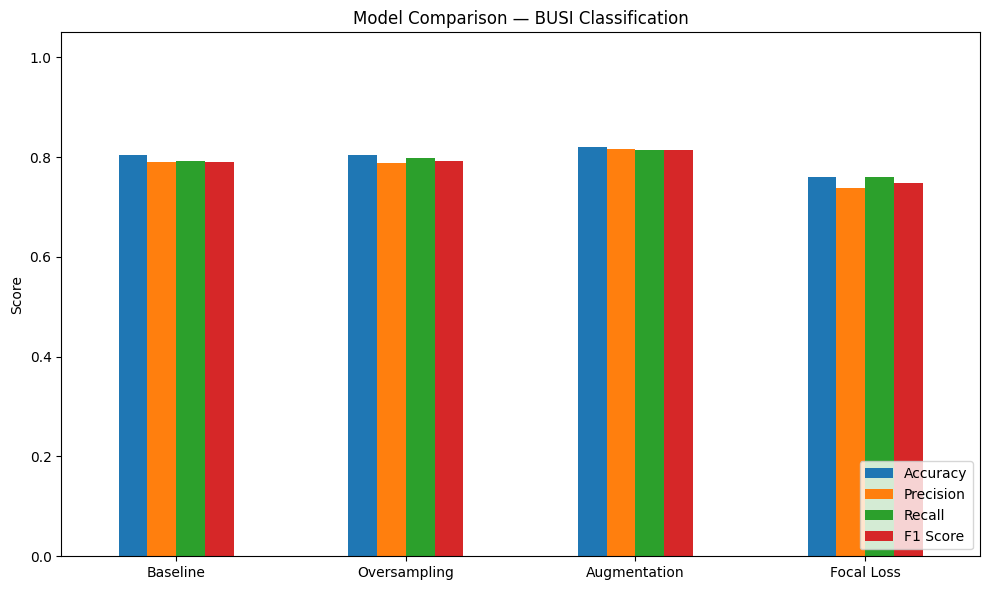

In [22]:
comparison_df = pd.DataFrame(results).T
print("\nFinal Model Comparison\n")
print(comparison_df.to_string())
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Model Comparison — BUSI Classification")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

